/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
HYBRID ENSEMBLE: EfficientNet + ViT
with Cross-Modal Attention Fusion

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5140 | Val: 572 | Test: 1311


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Total parameters: 93,649,666
Trainable parameters: 93,649,666

TRAINING STARTED
Epoch 01/30 | Train Loss: 0.3859 Acc: 0.8198 | Val Loss: 0.2781 Acc: 0.9178
  → Model saved! Best Val Acc: 0.9178
Epoch 02/30 | Train Loss: 0.2807 Acc: 0.9354 | Val Loss: 0.2535 Acc: 0.9598
  → Model saved! Best Val Acc: 0.9598
Epoch 03/30 | Train Loss: 0.2627 Acc: 0.9566 | Val Loss: 0.2403 Acc: 0.9650
  → Model saved! Best Val Acc: 0.9650
Epoch 04/30 | Train Loss: 0.2518 Acc: 0.9667 | Val Loss: 0.2323 Acc: 0.9825
  → Model saved! Best Val Acc: 0.9825
Epoch 05/30 | Train Loss: 0.2464 Acc: 0.9741 | Val Loss: 0.2350 Acc: 0.9755
Epoch 06/30 | Train Loss: 0.2374 Acc: 0.9823 | Val Loss: 0.2389 Acc: 0.9738
Epoch 07/30 | Train Loss: 0.2342 Acc: 0.9864 | Val Loss: 0.2328 Acc: 0.9825
Epoch 08/30 | Train Loss: 0.2342 Acc: 0.9864 | Val Loss: 0.2332 Acc: 0.9825
Epoch 09/30 | Train Loss: 0.2301 Acc: 0.9914 | Val Loss: 0.2385 Acc: 0.9738
Epoch 10/30 | Train Loss: 0.2322 Acc: 0.9883 | Val Loss: 0.2272 Acc: 0.9895
  → Mod

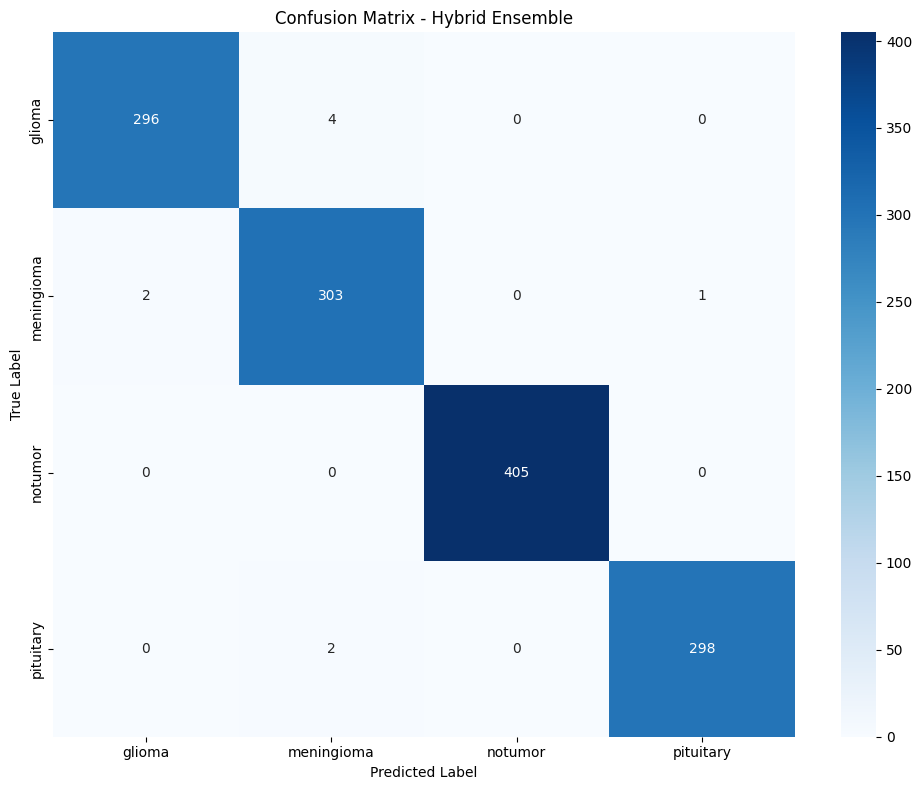


✅ Training complete!
📊 Best model saved as: best_hybrid_ensemble.pth


In [ ]:
"""
Tamim Mahmud from Daffodil International University 
Advanced Ensemble Framework for Brain Tumor Classification
Combining EfficientNet (CNN) + Vision Transformer (ViT) with Novel Fusion Mechanisms

Key Novelties:
1. Cross-Modal Attention Fusion (CMAF): Bidirectional attention between CNN and Transformer features
2. Hierarchical Multi-Scale Feature Extraction
3. Uncertainty-Aware Adaptive Weighting
4. Learnable Fusion Gates with Self-Attention
5. Monte Carlo Dropout for prediction confidence

"""

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import timm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# REPRODUCIBILITY
# ============================================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    # Paths (Corrected for Kaggle)
    data_root = "/kaggle/input/brain-tumor-mri-dataset"
    train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
    test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"
    
    # Training
    img_size = 224
    batch_size = 16
    epochs = 30
    lr = 1e-4
    weight_decay = 1e-4
    
    # Ensemble
    num_classes = 4
    cnn_feature_dim = 1280  # EfficientNet-B0 output
    vit_feature_dim = 768   # ViT-Base output
    fusion_dim = 512
    
    # Monte Carlo Dropout
    mc_dropout_samples = 10
    dropout_rate = 0.3

config = Config()

# ============================================================================
# NOVELTY 1: CROSS-MODAL ATTENTION FUSION (CMAF)
# ============================================================================
class CrossModalAttention(nn.Module):
    """
    Bidirectional attention mechanism between CNN and Transformer features.
    Allows each modality to attend to the other's representations.
    """
    def __init__(self, cnn_dim, vit_dim, hidden_dim=256, num_heads=8):
        super().__init__()
        
        self.cnn_proj = nn.Linear(cnn_dim, hidden_dim)
        self.vit_proj = nn.Linear(vit_dim, hidden_dim)
        
        # Multi-head cross-attention
        self.cross_attn_cnn_to_vit = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=0.1, batch_first=True
        )
        self.cross_attn_vit_to_cnn = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=0.1, batch_first=True
        )
        
        # Layer normalization
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        
    def forward(self, cnn_feat, vit_feat):
        # Project to common dimension
        cnn_proj = self.cnn_proj(cnn_feat).unsqueeze(1)  # [B, 1, H]
        vit_proj = self.vit_proj(vit_feat).unsqueeze(1)  # [B, 1, H]
        
        # CNN attends to ViT
        cnn_enhanced, _ = self.cross_attn_cnn_to_vit(
            cnn_proj, vit_proj, vit_proj
        )
        cnn_enhanced = self.ln1(cnn_enhanced + cnn_proj).squeeze(1)
        
        # ViT attends to CNN
        vit_enhanced, _ = self.cross_attn_vit_to_cnn(
            vit_proj, cnn_proj, cnn_proj
        )
        vit_enhanced = self.ln2(vit_enhanced + vit_proj).squeeze(1)
        
        return cnn_enhanced, vit_enhanced

# ============================================================================
# NOVELTY 2: ADAPTIVE FUSION GATE
# ============================================================================
class AdaptiveFusionGate(nn.Module):
    """
    Learnable gating mechanism that dynamically weighs CNN and ViT features
    based on input characteristics and prediction confidence.
    """
    def __init__(self, feature_dim):
        super().__init__()
        
        self.gate_network = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(feature_dim, 2),
            nn.Softmax(dim=1)
        )
        
    def forward(self, cnn_feat, vit_feat):
        # Concatenate features
        combined = torch.cat([cnn_feat, vit_feat], dim=1)
        
        # Compute adaptive weights [B, 2]
        weights = self.gate_network(combined)
        
        # Apply weights
        cnn_weight = weights[:, 0:1]
        vit_weight = weights[:, 1:2]
        
        fused = cnn_weight * cnn_feat + vit_weight * vit_feat
        
        return fused, weights

# ============================================================================
# NOVELTY 3: UNCERTAINTY-AWARE PREDICTION HEAD
# ============================================================================
class UncertaintyHead(nn.Module):
    """
    Prediction head with Monte Carlo Dropout for uncertainty estimation.
    Provides both prediction and confidence scores.
    """
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super().__init__()
        
        self.dropout_rate = dropout_rate
        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x, mc_dropout=False):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x) if (self.training or mc_dropout) else x
        x = F.relu(self.fc2(x))
        x = self.dropout2(x) if (self.training or mc_dropout) else x
        x = self.fc3(x)
        return x
    
    def predict_with_uncertainty(self, x, n_samples=10):
        """Monte Carlo Dropout for uncertainty estimation"""
        self.eval()
        predictions = []
        
        for _ in range(n_samples):
            with torch.no_grad():
                pred = self.forward(x, mc_dropout=True)
                predictions.append(F.softmax(pred, dim=1))
        
        predictions = torch.stack(predictions)  # [n_samples, batch, classes]
        
        # Mean prediction
        mean_pred = predictions.mean(dim=0)
        
        # Uncertainty (variance)
        uncertainty = predictions.var(dim=0).mean(dim=1)
        
        return mean_pred, uncertainty

# ============================================================================
# MAIN ENSEMBLE MODEL
# ============================================================================
class HybridEnsemble(nn.Module):
    """
    Advanced Ensemble combining EfficientNet and Vision Transformer
    with Cross-Modal Attention Fusion and Uncertainty Estimation
    """
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        
        # CNN Branch: EfficientNet-B0
        self.efficientnet = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            num_classes=0,  # Remove classifier
            global_pool=''  # Remove global pooling
        )
        
        # ViT Branch: Vision Transformer
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0  # Remove classifier
        )
        
        # Global pooling for CNN
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)
        
        # Cross-Modal Attention Fusion
        self.cross_attention = CrossModalAttention(
            cnn_dim=config.cnn_feature_dim,
            vit_dim=config.vit_feature_dim,
            hidden_dim=config.fusion_dim
        )
        
        # Adaptive Fusion Gate
        self.fusion_gate = AdaptiveFusionGate(config.fusion_dim)
        
        # Uncertainty-Aware Prediction Head
        self.classifier = UncertaintyHead(
            config.fusion_dim,
            num_classes,
            dropout_rate=config.dropout_rate
        )
        
    def forward(self, x, return_features=False):
        # Extract CNN features
        cnn_feat = self.efficientnet(x)
        cnn_feat = self.cnn_pool(cnn_feat).flatten(1)
        
        # Extract ViT features
        vit_feat = self.vit.forward_features(x)
        vit_feat = vit_feat[:, 0]  # CLS token
        
        # Cross-Modal Attention
        cnn_enhanced, vit_enhanced = self.cross_attention(cnn_feat, vit_feat)
        
        # Adaptive Fusion
        fused_feat, fusion_weights = self.fusion_gate(cnn_enhanced, vit_enhanced)
        
        # Classification
        logits = self.classifier(fused_feat)
        
        if return_features:
            return logits, {
                'cnn_feat': cnn_feat,
                'vit_feat': vit_feat,
                'fused_feat': fused_feat,
                'fusion_weights': fusion_weights
            }
        
        return logits
    
    def predict_with_uncertainty(self, x):
        """Prediction with uncertainty estimation"""
        self.eval()
        
        # Extract and fuse features
        with torch.no_grad():
            cnn_feat = self.efficientnet(x)
            cnn_feat = self.cnn_pool(cnn_feat).flatten(1)
            
            vit_feat = self.vit.forward_features(x)
            vit_feat = vit_feat[:, 0]
            
            cnn_enhanced, vit_enhanced = self.cross_attention(cnn_feat, vit_feat)
            fused_feat, _ = self.fusion_gate(cnn_enhanced, vit_enhanced)
        
        # MC Dropout prediction
        mean_pred, uncertainty = self.classifier.predict_with_uncertainty(
            fused_feat, n_samples=config.mc_dropout_samples
        )
        
        return mean_pred, uncertainty

# ============================================================================
# FOCAL LOSS WITH LABEL SMOOTHING
# ============================================================================
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
    
    def forward(self, logits, target):
        log_probs = F.log_softmax(logits, dim=-1)
        probs = torch.exp(log_probs)
        
        # Label smoothing
        n_classes = logits.size(-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        
        # Focal loss
        focal_weight = (1.0 - probs) ** self.gamma
        loss = -self.alpha * focal_weight * true_dist * log_probs
        
        return loss.sum(dim=1).mean()

# ============================================================================
# DATA LOADING
# ============================================================================
def get_dataloaders(config):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(config.img_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225]),
    ])
    
    eval_transform = transforms.Compose([
        transforms.Resize((config.img_size, config.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])
    
    # Load datasets
    full_train = datasets.ImageFolder(config.train_dir)
    test_dataset = datasets.ImageFolder(config.test_dir, transform=eval_transform)
    
    # Train/Val split
    indices = list(range(len(full_train)))
    random.shuffle(indices)
    train_size = int(0.9 * len(indices))
    train_idx, val_idx = indices[:train_size], indices[train_size:]
    
    train_full = datasets.ImageFolder(config.train_dir, transform=train_transform)
    val_full = datasets.ImageFolder(config.train_dir, transform=eval_transform)
    
    train_dataset = Subset(train_full, train_idx)
    val_dataset = Subset(val_full, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size,
                             shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size,
                           shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size,
                            shuffle=False, num_workers=2, pin_memory=True)
    
    class_names = full_train.classes
    
    return train_loader, val_loader, test_loader, class_names

# ============================================================================
# TRAINING
# ============================================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return running_loss / total, correct / total

# ============================================================================
# COMPREHENSIVE EVALUATION
# ============================================================================
def comprehensive_evaluation(model, loader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_uncertainties = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            
            # Get predictions with uncertainty
            probs, uncertainty = model.predict_with_uncertainty(images)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            all_uncertainties.extend(uncertainty.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    all_uncertainties = np.array(all_uncertainties)
    
    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )
    
    print("\n" + "="*60)
    print("COMPREHENSIVE EVALUATION RESULTS")
    print("="*60)
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"Mean Uncertainty: {all_uncertainties.mean():.4f}")
    
    print("\nPer-Class Metrics:")
    print(classification_report(all_labels, all_preds, 
                                target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Hybrid Ensemble')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'uncertainties': all_uncertainties
    }

# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================
def main():
    print("="*60)
    print("HYBRID ENSEMBLE: EfficientNet + ViT")
    print("with Cross-Modal Attention Fusion")
    print("="*60)
    
    # Load data
    train_loader, val_loader, test_loader, class_names = get_dataloaders(config)
    print(f"\nClasses: {class_names}")
    print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")
    
    # Build model
    model = HybridEnsemble(num_classes=config.num_classes).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Loss and optimizer
    criterion = FocalLossWithSmoothing(alpha=1.0, gamma=2.0, smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, 
                                  weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    
    # Training
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print("\n" + "="*60)
    print("TRAINING STARTED")
    print("="*60)
    
    for epoch in range(1, config.epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch:02d}/{config.epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_hybrid_ensemble.pth')
            print(f"  → Model saved! Best Val Acc: {best_val_acc:.4f}")
    
    # Load best model
    model.load_state_dict(torch.load('best_hybrid_ensemble.pth'))
    
    # Final evaluation
    print("\n" + "="*60)
    print("FINAL TEST SET EVALUATION")
    print("="*60)
    results = comprehensive_evaluation(model, test_loader, class_names, device)
    
    return model, history, results

# ============================================================================
# RUN
# ============================================================================
if __name__ == "__main__":
    model, history, results = main()
    print("\n✅ Training complete!")
    print("📊 Best model saved as: best_hybrid_ensemble.pth")